In [5]:
import pickle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo.basedataset import BaseDataset
from neuralhydrology.datasetzoo.lamah import LamaH
from neuralhydrology.utils.config import Config

In [6]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    start_run(config_file=Path("basin_1_lamah.yml"))

# fall back to CPU-only mode
else:
    start_run(config_file=Path("basin_1_lamah.yml"), gpu=-1)

2024-03-26 15:19:28,694: Logging to /home/sngrjohn/GitHub/neuralhydrology/msc_charlotte/single_basin_runs/id_1/runs/test_run_lamah_2603_151928/output.log initialized.
2024-03-26 15:19:28,695: ### Folder structure created at /home/sngrjohn/GitHub/neuralhydrology/msc_charlotte/single_basin_runs/id_1/runs/test_run_lamah_2603_151928
2024-03-26 15:19:28,696: ### Run configurations for test_run_lamah
2024-03-26 15:19:28,697: experiment_name: test_run_lamah
2024-03-26 15:19:28,698: train_basin_file: 1_basin_lamah.txt
2024-03-26 15:19:28,698: validation_basin_file: 1_basin_lamah.txt
2024-03-26 15:19:28,699: test_basin_file: 1_basin_lamah.txt
2024-03-26 15:19:28,700: train_start_date: 1995-01-12 00:00:00
2024-03-26 15:19:28,701: train_end_date: 2014-06-16 00:00:00
2024-03-26 15:19:28,701: validation_start_date: 2012-01-12 00:00:00
2024-03-26 15:19:28,702: validation_end_date: 2013-01-12 00:00:00
2024-03-26 15:19:28,703: test_start_date: 2013-01-12 00:00:00
2024-03-26 15:19:28,703: test_end_date

2024-03-26 15:19:28,754: Loading basin data into xarray data set.
100%|██████████| 1/1 [00:00<00:00,  9.50it/s]
2024-03-26 15:19:28,884: Create lookup table and convert to pytorch tensor
# Epoch 1: 100%|██████████| 27/27 [00:01<00:00, 19.79it/s, Loss: 0.1224]
2024-03-26 15:19:32,344: Epoch 1 average loss: avg_loss: 0.23358, avg_total_loss: 0.23358
# Epoch 2: 100%|██████████| 27/27 [00:01<00:00, 24.14it/s, Loss: 0.0927]
2024-03-26 15:19:33,470: Epoch 2 average loss: avg_loss: 0.14694, avg_total_loss: 0.14694
# Epoch 3: 100%|██████████| 27/27 [00:01<00:00, 24.35it/s, Loss: 0.0788]
2024-03-26 15:19:34,586: Epoch 3 average loss: avg_loss: 0.11928, avg_total_loss: 0.11928
# Validation: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]
2024-03-26 15:19:35,513: Epoch 3 average validation loss: 0.11764 -- Median validation metrics: avg_loss: 0.11764, NSE: 0.77711
# Epoch 4: 100%|██████████| 27/27 [00:01<00:00, 24.39it/s, Loss: 0.0764]
2024-03-26 15:19:36,624: Epoch 4 average loss: avg_loss: 0.1053

In [7]:
run_dir = Path("runs/test_run_lamah_2603_151928")
eval_run(run_dir=run_dir, period="test")

2024-03-26 15:21:24,040: Using the model weights from runs/test_run_lamah_2603_151928/model_epoch050.pt
# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  5.53it/s]
2024-03-26 15:21:24,229: Stored metrics at runs/test_run_lamah_2603_151928/test/model_epoch050/test_metrics.csv
2024-03-26 15:21:24,230: Stored results at runs/test_run_lamah_2603_151928/test/model_epoch050/test_results.p


In [8]:
with open(run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
results.keys()

dict_keys(['1'])

In [9]:
results['1']['1D']['xr']

<xarray.Dataset>
Dimensions:    (date: 366, time_step: 1)
Coordinates:
  * date       (date) datetime64[ns] 2013-01-12 2013-01-13 ... 2014-01-12
  * time_step  (time_step) int64 0
Data variables:
    qobs_obs   (date, time_step) float32 1.929 1.726 1.896 ... 1.538 1.491 1.406
    qobs_sim   (date, time_step) float32 1.792 1.831 1.861 ... 1.522 1.535 1.442

In [10]:
# plot predictions vs. observations
results['1']['1D']['xr'].keys()

KeysView(<xarray.Dataset>
Dimensions:    (date: 366, time_step: 1)
Coordinates:
  * date       (date) datetime64[ns] 2013-01-12 2013-01-13 ... 2014-01-12
  * time_step  (time_step) int64 0
Data variables:
    qobs_obs   (date, time_step) float32 1.929 1.726 1.896 ... 1.538 1.491 1.406
    qobs_sim   (date, time_step) float32 1.792 1.831 1.861 ... 1.522 1.535 1.442)

Text(0.5, 1.0, 'Test period - NSE 0.969')

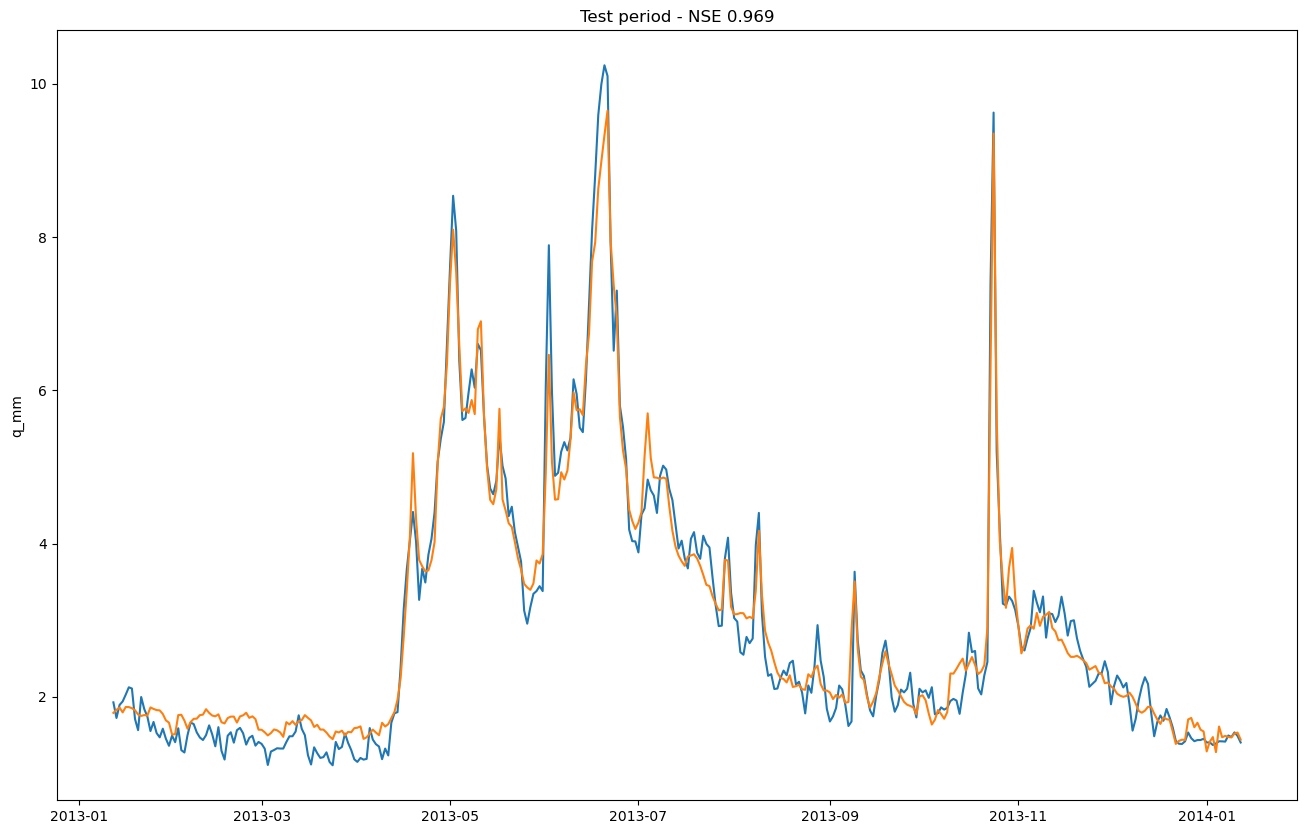

In [11]:
# extract observations and simulations
qobs = results['1']['1D']['xr']['qobs_obs']
qsim = results['1']['1D']['xr']['qobs_sim']

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['date'], qobs)
ax.plot(qsim['date'], qsim)
ax.set_ylabel("q_mm")
ax.set_title(f"Test period - NSE {results['1']['1D']['NSE']:.3f}")

In [12]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.969
MSE: 0.101
RMSE: 0.318
KGE: 0.924
Alpha-NSE: 0.926
Beta-KGE: 1.010
Beta-NSE: 0.017
Pearson-r: 0.986
FHV: -7.347
FMS: -6.150
FLV: 6.382
Peak-Timing: 0.500
Peak-MAPE: 5.875


/home/sngrjohn/anaconda3/envs/neuralhydrology/lib/python3.10/site-packages/neuralhydrology/datautils/utils.py:327: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/home/sngrjohn/anaconda3/envs/neuralhydrology/lib/python3.10/site-packages/neuralhydrology/datautils/utils.py:368: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)
